<a href="https://colab.research.google.com/github/kimjiwoo2/Pill-agent/blob/develop/notebooks/yoonsoo/ys_ocr%20baseline%200607.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pill Imprint OCR Baseline


## 0. Colab setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q \
    opencv-python-headless \
    pandas numpy matplotlib tqdm rapidfuzz
!pip install -q paddlepaddle paddleocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7

In [ ]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import cv2
import numpy as np
import pandas as pd
from rapidfuzz.distance import Levenshtein
from tqdm.auto import tqdm


## 1. Paths

In [ ]:
ZIP_PATH = "/content/drive/MyDrive/Pillot/dataset/pilliot_15k_optimized_leakage_free_split.zip"
!unzip -q "{ZIP_PATH}" -d /content

In [ ]:
DATA_ROOT = Path("/content/pilliot_15k_optimized_leakage_free_split")

MANIFEST_DIR = DATA_ROOT / "manifests"
IMAGE_ROOT   = DATA_ROOT / "images"

WORK_DIR   = Path("/content/pillot_ocr_work")
CROP_DIR   = WORK_DIR / "crops"
RESULT_DIR = WORK_DIR / "results"

for d in [WORK_DIR, CROP_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)


## 2. Manifest loading & target 레이블 정의

In [ ]:
IGNORE_IMPRINT_TOKENS = {
    "", "NAN", "NONE", "NULL", "마크", "분할선", "없음", "무", "-",
}

# 각인 라벨/예측값을 비교 가능한 형태로 정규화.
def normalize_imprint(text: object, keep_separator: bool = False) -> str:
    if pd.isna(text):   # NaN -> "" 반환
        return ""
    text = str(text).strip()
    if text.upper() in IGNORE_IMPRINT_TOKENS:  # IGNORE 리스트 해당 -> "" 반환
        return ""
    text = text.upper()   # 대문자 변환
    text = re.sub(r"\s+", "", text)   # 공백 제거
    text = text.replace("분할선", "").replace("마크", "")   # 분할선, 마크 포함되어 있을 시 제거
    allowed = r"[^0-9A-Z가-힣+\-/|]" if keep_separator else r"[^0-9A-Z가-힣+\-/]" # 허용 문자 외 제거(숫자, 영문, 한글, +, , / 만 유지)
    text = re.sub(allowed, "", text)
    if text.upper() in IGNORE_IMPRINT_TOKENS:  # 정리 후 다시 IGNORE 리스트 체크
        return ""
    return text

# 현재 사용 중인 manifest(bbox_manifest_val_with_attributes.csv)에는 drug_dir 컬럼이 없으므로 항상 else(양면 후보) 분기로 동작함.
# drug_dir이 포함된 manifest 사용 시 자동으로 앞/뒷면 분기 활성화됨.
def build_target_for_row(row: pd.Series) -> dict:
    """
    한 행의 정답 정보를 계산
    drug_dir 컬럼이 있으면:
      - '앞면' → print_front만 정답
      - '뒷면' → print_back만 정답
    drug_dir이 없거나 알 수 없으면:
      - front/back 둘 다 후보 → target_text = 'FRONT/BACK'
    """
    front = normalize_imprint(row.get("print_front", ""))
    back  = normalize_imprint(row.get("print_back",  ""))

    # drug_dir 우선 활용
    drug_dir = str(row.get("drug_dir", "")).strip()
    if drug_dir == "앞면" and front:
        target = front
        candidates = [front]
    elif drug_dir == "뒷면" and back:
        target = back
        candidates = [back]
    else:
        # drug_dir 없는 경우 → 후보 방식
        candidates = [t for t in [front, back] if t]
        candidates = list(dict.fromkeys(candidates))  # dedup 순서 유지
        target = "/".join(candidates)

    return {
        "target_text_front": front,   # 표시용 (앞면 정규화값)
        "target_text_back":  back,    # 표시용 (뒷면 정규화값)
        "target_candidates": candidates,
        "target_text":       target,
    }


def normalize_prediction(text: object) -> str:
    return normalize_imprint(text, keep_separator=False)  # OCR 예측값에서 분할선(|) 제외 -> 정답 레이블과 형식 통일


def load_manifest(data_root: Path,
                  manifest_name: str = "bbox_manifest_all_with_attributes.csv") -> pd.DataFrame:
    path = data_root / "manifests" / manifest_name
    if not path.exists():   # 파일 없으면 즉시 에러 산출(이후 코드 실행 방지)
        raise FileNotFoundError(f"Manifest not found: {path}")
    df = pd.read_csv(path, low_memory=False)  # CSV 로드
    required = {"dataset_type", "split_type", "image_file"}  # 필수 컬럼 3개 존재 여부 검증
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    return df

# OCR 평가 후보 필터링
def filter_ocr_candidates(
    df: pd.DataFrame,
    dataset_type: Optional[str] = "single",  # 사용할 dataset_type. None이면 미적용
    limit: Optional[int] = None,          # 최대 샘플 수 제한. None이면 전체 사용
    seed: int = 42,                        # limit 적용 시 랜덤 셔플 재현성 보장용 시드
) -> pd.DataFrame:

    # 원본 df를 수정하지 않기 위해 복사본으로 작업
    out = df.copy()

    # ── 필터 1: for_ocr_eval_candidate ──────────────────────────────────────
    # 이 컬럼이 있는 manifest에서만 적용 (없는 경우 스킵)
    # "true" 인 행만 OCR 평가 대상으로 사전 지정된 샘플
    if "for_ocr_eval_candidate" in out.columns:
        out = out[out["for_ocr_eval_candidate"].astype(str).str.lower().eq("true")]

    # ── 필터 2: has_print ───────────────────────────────────────────────────
    # has_print=True인 행만 유지 (전부 has_print=T인거 알지만 방어용)
    if "has_print" in out.columns:
        out = out[out["has_print"]]

    # ── 필터 3: dataset_type ─────────────────────────────────────────────────
    # "single"만 사용. "combination"(복합제)은 각인 구조가 달라 현재 파이프라인 제외
    if dataset_type:
        out = out[out["dataset_type"].eq(dataset_type)]

    # ── 빈 DataFrame 예외 처리 ───────────────────────────────────────────────
    # 필터 후 행이 0개면 target 컬럼 4개만 빈 채로 추가하고 early return
    # 이후 코드에서 target 컬럼이 없어 KeyError가 나는 상황 방지
    if out.empty:
        empty_target_cols = pd.DataFrame(columns=[
            "target_text_front", "target_text_back", "target_candidates", "target_text"
        ])
        out = pd.concat([out, empty_target_cols], axis=1)
        return out.reset_index(drop=True)

    # ── target 컬럼 생성 ─────────────────────────────────────────────────────
    # 각 행에 build_target_for_row() 적용 → 4개 컬럼 반환
    # result_type="expand": dict 반환값을 자동으로 컬럼으로 펼쳐줌
    target_cols = out.apply(build_target_for_row, axis=1, result_type="expand")
    out = pd.concat([out, target_cols], axis=1)

    # ── 필터 4: target_text가 빈 문자열인 행 제거 ────────────────────────────
    # normalize 후 정답이 없는 행 (마크만 있는 경우, print_front null 4건 등)
    out = out[out["target_text"].ne("")]

    # ── limit: 샘플 수 제한 ──────────────────────────────────────────────────
    # 빠른 실험용으로 일부 샘플만 쓸 때 사용. None이면 전체 사용
    if limit:
        import random
        random.seed(seed)

        # item_seq(약품 코드) 단위로 그룹화
        # → 같은 약품의 이미지가 일부만 잘리는 상황 방지
        #   ex) limit=100일 때 어떤 약품이 60장이면 통째로 포함하거나 제외
        groups = out.groupby("item_seq")
        all_kinds = list(groups.groups.keys())
        random.shuffle(all_kinds)  # 매번 같은 순서로 선택되지 않도록 셔플

        selected, total = [], 0
        for kind in all_kinds:
            count = len(groups.get_group(kind))

            # 이 약품을 추가했을 때 limit을 초과하면 스킵
            # (딱 맞게 채우지 않고 초과 방지 우선)
            if total + count > limit:
                continue

            selected.append(kind)
            total += count

            # limit의 90% 이상 채워지면 조기 종료
            # (100% 채우려다 무한루프 방지 + 적당한 수준에서 마감)
            if total >= limit * 0.9:
                break

        out = out[out["item_seq"].isin(selected)]

    # 인덱스 초기화 후 반환 (0, 1, 2, ... 으로 재정렬)
    return out.reset_index(drop=True)


df_val  = load_manifest(DATA_ROOT, manifest_name="bbox_manifest_val_with_attributes.csv")
df_eval = filter_ocr_candidates(df_val, dataset_type="single")
print(f"df_val: {df_val.shape}, df_eval: {df_eval.shape}")
display(df_eval[["image_file", "target_text_front", "target_text_back", "target_text"]])


df_val: (3784, 40), df_eval: (2361, 44)


,image_file,target_text_front,target_text_back,target_text
0,K-035736_0_0_0_0_90_080_200.png,JRP20,,JRP20
1,K-035736_0_0_0_1_75_100_200.png,JRP20,,JRP20
2,K-035736_0_0_0_1_90_000_200.png,JRP20,,JRP20
3,K-035736_0_0_0_1_90_040_200.png,JRP20,,JRP20
4,K-035736_0_0_0_2_75_000_200.png,JRP20,,JRP20
...,...,...,...,...
2356,K-036018_0_0_0_1_75_020_200.png,RX,60,RX/60
2357,K-036018_0_0_0_2_90_020_200.png,RX,60,RX/60
2358,K-036018_0_0_0_2_90_180_200.png,RX,60,RX/60
2359,K-036018_0_0_1_1_90_060_200.png,RX,60,RX/60


**target_text 구조 설명:**
- `target_text_front` / `target_text_back`: 각각 `normalize_imprint(print_front/back)`. 표시/디버깅용.
- `target_text`: 실제 평가 기준. `drug_dir`이 '앞면'이면 front만, '뒷면'이면 back만. 모를 땐 `FRONT/BACK` 형태.
- `target_candidates`: 평가 시 "후보 중 하나와 일치하면 정답"으로 사용.


## 3. Image path resolving

In [ ]:
def _zip_stem(name: str) -> str:
    return Path(str(name)).stem

# manifest 한 행에서 실제 이미지 파일 경로를 조합해 반환.
def resolve_image_path(row: pd.Series, data_root: Path = DATA_ROOT) -> Path:
    """
    경로 구조:
        {data_root}/images/{split}/{dataset_type}/{image_zip_stem}/{image_file}
        ex) .../images/val/single/TS_76_단일/K-035736_0_0_0_0_90_080_200.png

    split 컬럼 우선 사용, 없으면 split_type 폴백.
    (split_type만 쓰면 실제 저장 경로와 불일치 발생 — 184/471건 누락 확인됨)
    """
    split_col      = row["split"] if "split" in row.index else row.get("split_type", "train")
    dataset_type   = str(row["dataset_type"])
    image_zip_stem = _zip_stem(row["image_zip_name"])  # zip 파일명에서 확장자 제거
    image_file     = str(row["image_file"])
    return data_root / "images" / str(split_col) / dataset_type / image_zip_stem / image_file


def report_missing_images(df: pd.DataFrame, n: int = 10) -> None:
    paths = df.apply(resolve_image_path, axis=1)
    missing = [not p.exists() for p in paths]
    print(f"이미지 확인: {sum(not m for m in missing)} 존재 / {sum(missing)} 누락 (총 {len(df)})")
    if any(missing):
        print("누락 zip 목록:")
        print(df[missing]["image_zip_name"].value_counts().head(n))


report_missing_images(df_eval)


이미지 확인: 2361 존재 / 0 누락 (총 2361)


## 4. 공통 전처리

In [ ]:
@dataclass
class CommonPreprocessConfig:
    apply_awb: bool = True                          # AWB(자동 화이트밸런스) 적용 여부
    denoise_method: str = "bilateral"               # 노이즈 제거 방식: "none" | "bilateral" | "nlm"
    bilateral_d: int = 5                            # bilateral 필터 커널 직경 (홀수 권장, 클수록 느림)
    bilateral_sigma_color: int = 35                 # 색상 공간 sigma (클수록 넓은 색상 범위를 평활화)
    bilateral_sigma_space: int = 35                 # 좌표 공간 sigma (클수록 먼 픽셀까지 영향)
    nlm_h: int = 3                                  # NLM 노이즈 제거 강도 (클수록 강하게 제거, 디테일 손실 증가)


def read_bgr(path: Path) -> np.ndarray:
    path = Path(path)
    suffix = path.suffix.lower()

    # HEIC/HEIF 포맷 처리 (iPhone 촬영 이미지 등)
    # cv2.imread가 HEIC를 지원하지 않으므로 pillow-heif로 별도 처리
    if suffix in {".heic", ".heif"}:
        try:
            import pillow_heif
            from PIL import Image
            pillow_heif.register_heif_opener()
            rgb = np.array(Image.open(path).convert("RGB"))
            return cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)  # PIL은 RGB → cv2용 BGR로 변환
        except ImportError as exc:
            raise ImportError("pillow-heif 필요: pip install pillow-heif") from exc

    # 일반 포맷 (PNG, JPG 등) — IMREAD_UNCHANGED로 원본 채널 그대로 읽기
    image = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if image is None:
        raise FileNotFoundError(path)

    # 채널 수에 따라 BGR 3채널로 통일
    if image.ndim == 2:                 # grayscale → BGR
        return cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    if image.shape[2] == 4:            # BGRA(투명도 포함) → BGR (알파채널 제거)
        return cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)
    return image                        # 이미 BGR 3채널이면 그대로 반환


def gray_world_awb_bgr(image_bgr: np.ndarray) -> np.ndarray:
    """
    Gray World 가정 기반 자동 화이트밸런스(AWB).
    "이미지 전체의 평균 색상은 무채색(회색)이어야 한다"는 가정 하에
    각 채널의 평균값을 전체 평균에 맞게 스케일 조정.
    조명 색온도 편차가 큰 알약 촬영 이미지에 유효.
    """
    image = image_bgr.astype(np.float32)            # 연산 정밀도를 위해 float32 변환
    means = image.reshape(-1, 3).mean(axis=0)       # B/G/R 각 채널의 평균값 계산
    gray_mean = means.mean()                        # 세 채널 평균의 평균 → 목표 밝기
    scale = gray_mean / np.maximum(means, 1e-6)     # 채널별 스케일 계산 (0 나눗셈 방지: 1e-6)
    return np.clip(image * scale, 0, 255).astype(np.uint8)  # 스케일 적용 후 0~255 범위로 클리핑


def denoise_bgr(image_bgr: np.ndarray, cfg: CommonPreprocessConfig) -> np.ndarray:
    if cfg.denoise_method == "none":
        return image_bgr                            # 노이즈 제거 스킵

    if cfg.denoise_method == "bilateral":
        # bilateral 필터: 엣지(경계선)를 보존하면서 노이즈 제거
        # 일반 blur와 달리 색상 차이가 큰 경계(각인 윤곽)는 평활화하지 않음
        return cv2.bilateralFilter(image_bgr, cfg.bilateral_d,
                                   cfg.bilateral_sigma_color, cfg.bilateral_sigma_space)

    if cfg.denoise_method == "nlm":
        # NLM(Non-Local Means): 유사한 패턴을 가진 픽셀끼리 평균 → bilateral보다 품질 높으나 느림
        # 7: 탐색 윈도우 크기, 21: 비교 패치 크기
        return cv2.fastNlMeansDenoisingColored(image_bgr, None, cfg.nlm_h, cfg.nlm_h, 7, 21)

    raise ValueError(f"Unknown denoise_method: {cfg.denoise_method}")  # 잘못된 옵션 즉시 에러


# AWB → denoise 순서로 공통 전처리 적용. crop 전 원본 이미지에 사용.
def common_preprocess_bgr(
    image_bgr: np.ndarray,
    cfg: CommonPreprocessConfig = CommonPreprocessConfig()
) -> np.ndarray:
    out = image_bgr
    if cfg.apply_awb:
        out = gray_world_awb_bgr(out)   # AWB 적용
    out = denoise_bgr(out, cfg)         # 노이즈 제거
    return out

## 5. bbox 기반 알약 crop 생성 및 2차 OCR 전처리

In [ ]:
@dataclass
class CropConfig:
    margin_ratio: float = 0.16          # bbox 주변 여백 비율 (bbox 최대 변 길이의 16%)
    min_size: int = 96                  # crop 결과가 이 크기 미만이면 원본 이미지 전체 반환
    target_size: int = 384              # enhance_crop_for_ocr_bgr()에서 리사이즈할 목표 해상도
    use_bbox: bool = True               # False면 bbox crop 없이 원본 이미지 그대로 사용
    apply_common_preprocess: bool = True  # False면 AWB/denoise 전처리 스킵


def crop_with_bbox(image_bgr: np.ndarray, row: pd.Series, cfg: CropConfig) -> np.ndarray:
    h, w = image_bgr.shape[:2]

    # use_bbox=False이거나 bbox 값 중 하나라도 NaN이면 원본 전체 반환
    if not cfg.use_bbox or any(pd.isna(row.get(k)) for k in ["bbox_x","bbox_y","bbox_w","bbox_h"]):
        return image_bgr

    x, y, bw, bh = [float(row[k]) for k in ["bbox_x","bbox_y","bbox_w","bbox_h"]]

    # bbox 최대 변 길이 기준으로 여백 계산
    # ex) bbox가 200×100이면 margin = 0.16 × 200 = 32px
    margin = cfg.margin_ratio * max(bw, bh)

    # 여백 포함한 crop 좌표 계산
    # max(0, ...) / min(w or h, ...): 이미지 경계 밖으로 나가지 않도록 클리핑
    x1 = max(0, int(round(x - margin)))
    y1 = max(0, int(round(y - margin)))
    x2 = min(w, int(round(x + bw + margin)))
    y2 = min(h, int(round(y + bh + margin)))

    crop = image_bgr[y1:y2, x1:x2]

    # crop 결과가 min_size(96px) 미만이면 bbox가 너무 작거나 잘못된 것으로 판단
    if min(crop.shape[:2]) < cfg.min_size:
      print(f"[WARN] crop too small {crop.shape[:2]} → 원본 반환: {row.get('image_file')}")
      return image_bgr
    return crop

# 수정 — BGR로 반환
def enhance_crop_for_ocr_bgr(image_bgr: np.ndarray, target_size: int = 384) -> np.ndarray:
    h, w = image_bgr.shape[:2]
    # 긴 변 기준으로 target_size에 맞게 비율 유지 리사이즈
    # ex) 500×300 → scale=384/500=0.768 → 384×230
    # INTER_CUBIC: 업샘플링 시 품질이 INTER_LINEAR보다 좋음

    scale = target_size / max(h, w)
    if scale != 1:
        image_bgr = cv2.resize(image_bgr, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_CUBIC)
    # CLAHE(Contrast Limited Adaptive Histogram Equalization) 적용
    # 전역 히스토그램 평활화와 달리 타일 단위(8×8)로 지역 대비를 보정
    # 각인처럼 저대비 영역의 텍스트 경계를 강조하는 데 효과적

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    # PaddleOCR은 BGR 3채널 필요 → gray 후 BGR로 재변환
    return cv2.cvtColor(clahe.apply(gray), cv2.COLOR_GRAY2BGR)


def get_rotation_angle(image_file: str) -> int:
    """
    파일명에서 회전각 파싱.
    파일명 구조: K-035736_0_0_0_0_90_080_200.png
                                    ↑ 이 숫자가 회전각 (6번째 _ 구분자)
    """
    try:
        stem = Path(image_file).stem          # 확장자 제거
        parts = stem.split("_")               # _ 로 분리
        return int(parts[5])                  # 6번째 값이 회전각
    except (IndexError, ValueError):
        return 0                              # 파싱 실패 시 회전 없음으로 처리

# 파일명 회전각을 가장 가까운 90° 단위로 반올림해서 처리.
def rotate_image(image: np.ndarray, angle: int) -> np.ndarray:
    snapped = round(angle / 90) * 90 % 360

    if snapped == 0:
        return image
    elif snapped == 90:
        return cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    elif snapped == 180:
        return cv2.rotate(image, cv2.ROTATE_180)
    elif snapped == 270:
        return cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    return image


def make_crop(
    row: pd.Series,
    crop_cfg: CropConfig = CropConfig(),
    preprocess_cfg: CommonPreprocessConfig = CommonPreprocessConfig(),
) -> np.ndarray:
    # 한 행의 이미지를 읽어 전처리 → bbox crop → 회전 보정 → CLAHE 순서로 처리 후 반환.
    # pipeline: read_bgr → common_preprocess_bgr → crop_with_bbox → rotate → enhance_crop_for_ocr_bgr

    path = resolve_image_path(row)
    image_bgr = read_bgr(path)

    if crop_cfg.apply_common_preprocess:
        image_bgr = common_preprocess_bgr(image_bgr, preprocess_cfg)

    crop = crop_with_bbox(image_bgr, row, crop_cfg)


    angle = get_rotation_angle(str(row["image_file"]))
    crop = rotate_image(crop, angle)

    return enhance_crop_for_ocr_bgr(crop, crop_cfg.target_size)


def save_eval_crops(df: pd.DataFrame, out_dir: Path = CROP_DIR, limit: Optional[int] = None) -> pd.DataFrame:
    """
    df_eval 전체 행에 make_crop()을 적용하고 결과를 디스크에 저장.
    crop 경로(crop_path)를 추가한 DataFrame 반환.
    ⚠️ 디스크 저장 후 경로를 OCR에 넘기는 구조 → 반복 실험 시 I/O 오버헤드 발생
       OCR 성능이 안정되면 numpy 배열을 직접 OCR에 넘기는 방식으로 변경 예정
    """
    rows = df.head(limit).copy() if limit else df.copy()
    records, skip_reasons = [], []

    for idx, row in tqdm(rows.iterrows(), total=len(rows), desc="cropping"):
        try:
            crop_bgr = make_crop(row)

            # 파일명의 / \ 를 _ 로 치환해 경로 문제 방지
            safe_name = str(row["image_file"]).replace("/", "_").replace("\\", "_")

            # 파일명: {6자리 인덱스}_{원본 이미지명}
            # ex) 000042_K-035736_0_0_0_0_90_080_200.png
            out_path = out_dir / f"{idx:06d}_{safe_name}"
            cv2.imwrite(str(out_path), crop_bgr)

            # 원본 행 정보에 crop_path 컬럼 추가해서 records에 누적
            record = row.to_dict()
            record["crop_path"] = str(out_path)
            records.append(record)

        except Exception as exc:
            # 개별 이미지 실패 시 전체 중단 없이 skip — 오류 내용만 기록
            skip_reasons.append({"image_file": row.get("image_file"), "error": str(exc)})

    # skip된 건이 있으면 오류 유형별로 요약 출력
    if skip_reasons:
        skip_df = pd.DataFrame(skip_reasons)
        print(f"\nskip {len(skip_df)}건 — 오류 유형별 요약:")
        print(skip_df["error"].value_counts().head(10))

    return pd.DataFrame(records)


df_crops = save_eval_crops(df_eval, limit=100)
print(f"crop 완료: {len(df_crops)}건")
display(df_crops[["image_file", "target_text_front", "target_text_back", "target_text", "crop_path"]].head())

cropping:   0%|          | 0/100 [00:00<?, ?it/s]

crop 완료: 100건


,image_file,target_text_front,target_text_back,target_text,crop_path
0,K-035736_0_0_0_0_90_080_200.png,JRP20,,JRP20,/content/pillot_ocr_work/crops/000000_K-035736...
1,K-035736_0_0_0_1_75_100_200.png,JRP20,,JRP20,/content/pillot_ocr_work/crops/000001_K-035736...
2,K-035736_0_0_0_1_90_000_200.png,JRP20,,JRP20,/content/pillot_ocr_work/crops/000002_K-035736...
3,K-035736_0_0_0_1_90_040_200.png,JRP20,,JRP20,/content/pillot_ocr_work/crops/000003_K-035736...
4,K-035736_0_0_0_2_75_000_200.png,JRP20,,JRP20,/content/pillot_ocr_work/crops/000004_K-035736...


## 6. Paddle OCR

In [ ]:
# 버전 확인
import paddleocr
print(paddleocr.__version__)

3.6.0


In [ ]:
def run_paddleocr(df_crops: pd.DataFrame, gpu: bool = True) -> pd.DataFrame:
    """PaddleOCR 3.6.0 baseline. crop_path 이미지를 읽어 OCR 결과를 저장."""
    from paddleocr import PaddleOCR

    # PaddleOCR 3.6.0 API
    # lang="korean"  : 영문+숫자+한글 모두 인식
    # device         : "gpu" 또는 "cpu"
    # use_textline_orientation=True : 180° 회전 텍스트 자동 감지·보정 (3.x에서 use_angle_cls 대체)
    # text_rec_score_thresh         : 인식 신뢰도 threshold (낮을수록 더 많이 인식, 노이즈 증가)
    ocr_engine = PaddleOCR(
        lang="korean",
        device="gpu" if gpu else "cpu",
        use_textline_orientation=True,
        text_rec_score_thresh=0.5,      # 낮은 신뢰도 텍스트 필터링
        text_det_thresh=0.3,            # 텍스트 영역 감지 threshold
    )

    results = []

    for _, row in tqdm(df_crops.iterrows(), total=len(df_crops), desc="paddleocr"):
        lines = []
        try:
            # predict()는 list 반환 — 각 원소가 이미지 1장의 결과 딕셔너리
            # 결과 구조: {"rec_texts": [...], "rec_scores": [...], "rec_polys": [...]}
            preds = ocr_engine.predict(row["crop_path"])
            if preds:
                res = preds[0]  # 이미지 1장이므로 첫 번째 원소만 사용
                texts = res.get("rec_texts", [])
                scores = res.get("rec_scores", [])
                lines = list(zip(texts, scores))
        except Exception as exc:
            lines = []

        pieces = []
        for text, conf in lines:
            text = normalize_prediction(str(text))
            if text:
                pieces.append(text)

        pred   = "".join(pieces)
        target = str(row.get("target_text", ""))

        # EM: 예측값과 정답이 완전히 일치하면 1, 아니면 0
        em = int(pred == target)

        # CER(Character Error Rate): 글자 단위 편집거리 / 정답 길이
        if target:
            edit_dist = Levenshtein.distance(pred, target)
            cer = edit_dist / len(target)
        else:
            cer = 0.0

        record = row.to_dict()
        record["pred_text"] = pred
        record["em"]        = em
        record["cer"]       = round(cer, 4)
        results.append(record)

    out = pd.DataFrame(results)
    out.to_csv(RESULT_DIR / "paddleocr_results.csv", index=False, encoding="utf-8-sig")
    return out


paddle_results = run_paddleocr(df_crops, gpu=True)

print(f"Exact Match : {paddle_results['em'].mean():.3f}")
print(f"Mean CER    : {paddle_results['cer'].mean():.3f}")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
The specified device (GPU) is not available! Switching to CPU instead.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
The specified device (GPU) is not available! Switching to CPU instead.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
The specified device (GPU) is not available! Switching to CPU instead.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_mo

paddleocr:   0%|          | 0/100 [00:00<?, ?it/s]

Exact Match : 0.000
Mean CER    : 1.000


In [ ]:
display(
    paddle_results
    .sort_values("cer")   # CER 낮은 순(거의 맞은 것부터)
    [["image_file", "target_text", "pred_text", "em", "cer"]]
    .head(30)
)


,image_file,target_text,pred_text,em,cer
2328,K-023623_0_0_1_1_90_340_200.png,IDC,,0,1.0
2329,K-023623_0_0_1_2_90_300_200.png,IDC,,0,1.0
2330,K-023628_0_0_0_0_75_020_200.png,AG/LC,,0,1.0
2331,K-023628_0_0_0_0_90_260_200.png,AG/LC,,0,1.0
2332,K-023628_0_0_0_1_75_240_200.png,AG/LC,,0,1.0
2333,K-023628_0_0_0_2_75_200_200.png,AG/LC,,0,1.0
2334,K-023628_0_0_0_2_90_220_200.png,AG/LC,,0,1.0
2335,K-023628_0_0_1_0_75_200_200.png,AG/LC,,0,1.0
2320,K-023623_0_0_0_1_75_240_200.png,IDC,,0,1.0
2321,K-023623_0_0_0_1_90_340_200.png,IDC,,0,1.0


In [ ]:
print("pred_text 비어있는 비율:", (paddle_results["pred_text"] == "").mean())

pred_text 비어있는 비율: 0.3436123348017621
ocr_conf > 0 인 행 수: 298

ocr_conf 분포:
count    454.000000
mean       0.304564
std        0.358200
min        0.000000
25%        0.000000
50%        0.129262
75%        0.550505
max        0.999875
Name: ocr_conf, dtype: float64


## 7. Metrics

In [ ]:
# ──────────────────────────────────────────
# 평가 지표
#   - Exact Match (EM): 정규화 후 완전 일치 (후보 중 하나라도 일치)
#   - CER (Character Error Rate): Levenshtein / len(reference)
#   - WER placeholder: 각인은 대부분 단일 토큰이라 EM/CER이 주 지표
# ──────────────────────────────────────────

def best_candidate_cer(pred: str, candidates: list) -> float:
    """후보 중 CER이 가장 낮은 것을 반환."""
    if not candidates:
        return 1.0 if pred else 0.0
    best = min(
        Levenshtein.distance(pred, cand) / max(len(cand), 1)
        for cand in candidates
    )
    return min(best, 1.0)


def is_exact_match(pred: str, candidates: list) -> bool:
    return pred in candidates if candidates else (pred == "")


def evaluate_ocr(df: pd.DataFrame) -> pd.DataFrame:
    """
    easyocr_results에 em / cer 컬럼을 추가하고 요약 출력.
    candidates 컬럼이 없으면 target_text를 단일 후보로 사용.
    """
    res = df.copy()

    def get_candidates(row):
        cands = row.get("target_candidates", None)
        if isinstance(cands, list):
            return cands
        # CSV에서 로드 시 문자열로 저장된 경우 파싱
        if isinstance(cands, str):
            import ast
            try:
                return ast.literal_eval(cands)
            except Exception:
                pass
        # fallback: target_text를 '/'로 분리
        return [t for t in str(row.get("target_text","")).split("/") if t]

    res["_candidates"] = res.apply(get_candidates, axis=1)
    res["em"]  = res.apply(lambda r: is_exact_match(r["pred_text"], r["_candidates"]), axis=1)
    res["cer"] = res.apply(lambda r: best_candidate_cer(r["pred_text"], r["_candidates"]), axis=1)
    res = res.drop(columns=["_candidates"])

    n      = len(res)
    em_acc = res["em"].mean()
    mean_cer = res["cer"].mean()

    print("=" * 40)
    print(f"평가 샘플 수  : {n}")
    print(f"Exact Match  : {em_acc:.3f}  ({res['em'].sum()}/{n})")
    print(f"Mean CER     : {mean_cer:.3f}")
    print("=" * 40)

    # 실패 케이스 샘플
    fails = res[~res["em"]].sort_values("cer", ascending=False)
    print(f"\n[Exact Match 실패 — 상위 10건 (CER 높은 순)]")
    print(fails[["image_file","target_text","pred_text","cer"]].head(10).to_string(index=False))

    return res


eval_results = evaluate_ocr(paddle_results)
eval_results.to_csv(RESULT_DIR / "paddleocr_eval_results.csv", ...)


평가 샘플 수  : 454
Exact Match  : 0.013  (6/454)
Mean CER     : 0.925

[Exact Match 실패 — 상위 10건 (CER 높은 순)]
                     image_file target_text pred_text  cer  ocr_conf
K-025216_0_2_1_1_75_300_200.png         MMA            1.0  0.000000
K-025216_0_2_1_1_90_100_200.png         MMA            1.0  0.000000
K-025216_0_2_1_1_90_140_200.png         MMA            1.0  0.000000
K-025216_0_2_1_2_75_100_200.png         MMA            1.0  0.000000
K-025216_0_2_1_2_75_200_200.png         MMA            1.0  0.000000
K-025216_0_2_1_2_90_260_200.png         MMA            1.0  0.000000
K-036076_0_0_0_0_90_200_200.png      JRP/60         리  1.0  0.008504
K-025216_0_2_0_1_75_320_200.png         MMA         2  1.0  0.126473
K-025216_0_2_0_1_90_340_200.png         MMA         톤  1.0  0.025433
K-025216_0_2_0_2_90_340_200.png         MMA         톤  1.0  0.109821


## 8. 실패 케이스 분석

/tmp/ipykernel_568/2484642821.py:23: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_568/2484642821.py:23: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_568/2484642821.py:23: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_568/2484642821.py:23: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_568/2484642821.py:23: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Gl

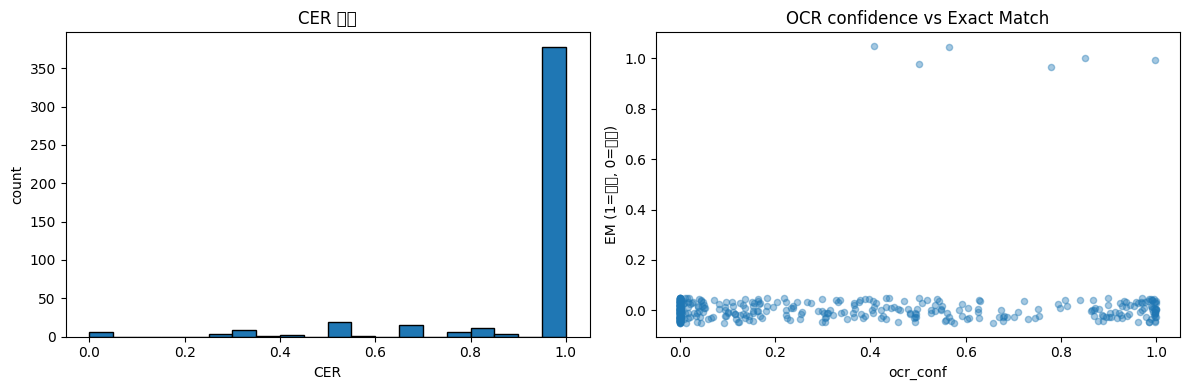


[target_text별 Exact Match 성공률]
              em_rate   n
target_text              
30           0.000000   5
4/80         0.000000   9
AJUCIT       0.000000   6
ANEDT        0.000000  17
AT50         0.000000   4
BD           0.000000   9
BD/HWP       0.000000   2
BP/R         0.000000   5
CLO          0.000000   6
D-W/LZ       0.000000   6
DACBC200     0.000000  11
E02          0.000000  10
HL145        0.000000   4
ERD          0.000000  18
HSP/213      0.000000   7
HNER         0.000000   2
KGC13        0.000000  12
JH/26        0.000000   6
HT/L50       0.000000   7
ID/U2        0.000000   1
IDPADS       0.000000  11
ID4          0.000000   7
IDS          0.000000   9
J73          0.000000   6
L24/HL       0.000000   4
KP/S5        0.000000   8
JRP/60       0.000000  12
JW3          0.000000  14
MC/S/M       0.000000   8
MMAT50       0.000000   5
MMA          0.000000  19
MJC          0.000000   5
카필러스카필러스     0.000000  16
UK/OC375     0.000000   9
WAL/15       0.000000   4
NK/15 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'  # Colab 한글 폰트

# CER 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(eval_results["cer"], bins=20, edgecolor="black")
axes[0].set_title("CER 분포")
axes[0].set_xlabel("CER")
axes[0].set_ylabel("count")


# target_text별 EM
print("\n[target_text별 Exact Match 성공률]")
print(
    eval_results.groupby("target_text")["em"]
    .agg(["mean","count"])
    .rename(columns={"mean":"em_rate","count":"n"})
    .sort_values("em_rate")
    .to_string()
)
